# Exploratory Data Analysis

In [1]:
import sys

# Necessary to import from src dir
sys.path.append('..')

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from itertools import combinations
from sklearn.decomposition import PCA

from src.pca import biplot, get_features_by_importance, plot_explained_variance
from src.preprocessing import prepare_standardized_datasets

In [3]:
DATA_DIR = r"./data/"
OUTPUT_DIR = r"./outputs/"

TRAIN_DATA = os.path.join(DATA_DIR, "train.csv")
TEST_DATA = os.path.join(DATA_DIR, "test.csv")

# Preprocessing

df_train = pd.read_csv(TRAIN_DATA)
df_test = pd.read_csv(TEST_DATA)

label_var = "class4"

# Include only the real-valued mean values, but don't exclude anything further than that yet before exploring the data a bit first
cols_to_include = [feat for feat in df_train.columns.to_list() if (feat.endswith(".mean")) or (feat == label_var)]

numeric_vars = cols_to_include[:]
numeric_vars.remove(label_var)

df_train_standardized, _, df_test_standardized = prepare_standardized_datasets(
    df_train=df_train,
    df_test=df_test,
    data_vars=numeric_vars,
    label_var=label_var,
    label_values=("nonevent", "event"),
    include_validation_split=False
)

df_train_standardized.head()

,class4,class2,CO2168.mean,CO2336.mean,CO242.mean,CO2504.mean,Glob.mean,H2O168.mean,H2O336.mean,H2O42.mean,...,SO2168.mean,SWS.mean,T168.mean,T42.mean,T504.mean,T672.mean,T84.mean,UV_A.mean,UV_B.mean,CS.mean
0,II,event,-0.867780,-0.883382,-0.929523,-0.878777,-0.513499,-0.783647,-0.779782,-0.781824,...,-0.456136,0.541758,-0.299145,-0.282750,-0.305683,-0.324836,-0.287664,-0.688861,-1.030310,-1.147189
1,nonevent,nonev,-0.823577,-0.839333,-0.882343,-0.833255,0.189801,-0.755609,-0.749101,-0.762649,...,-0.373313,0.466385,-0.702567,-0.679542,-0.713507,-0.736281,-0.688947,0.125321,-0.442983,-1.059902
2,Ia,event,-0.735765,-0.747661,-0.793051,-0.741507,1.233848,-0.837948,-0.834977,-0.833538,...,-0.271270,0.516825,-0.353630,-0.326983,-0.371040,-0.391842,-0.331950,0.890057,0.374255,-0.995347
3,Ib,event,-0.544192,-0.558780,-0.569606,-0.555771,1.371208,-0.746872,-0.739906,-0.742423,...,0.942006,0.535711,-0.202552,-0.191413,-0.222589,-0.245364,-0.179461,1.006066,0.862974,-0.445754
4,nonevent,nonev,-0.717947,-0.724841,-0.759015,-0.713551,-1.053162,-0.004673,-0.005885,-0.017888,...,-0.276519,-2.273178,-0.455287,-0.448823,-0.443364,-0.459731,-0.451326,-0.984617,-0.932361,-0.193122


## PCA

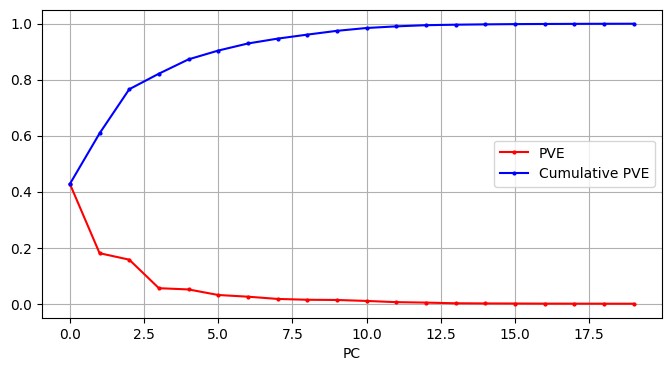

In [4]:
X_train = df_train_standardized[numeric_vars]
y_train = df_train_standardized[[label_var]]

pca = PCA(n_components=20)
pca_results = pca.fit(X_train)
scores = pca.transform(X_train)

fig, ax = plt.subplots(figsize=(8, 4))
plot_explained_variance(pca_results.explained_variance_ratio_, ax)

### PC1 & PC2

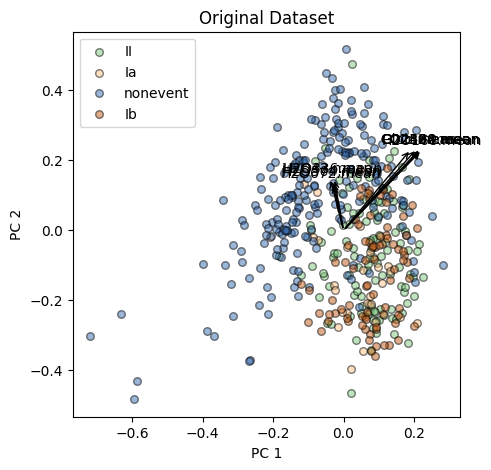

In [5]:
# Plot data projected to PC1 & PC2

fig, ax = plt.subplots(figsize=(5, 5))
top_features = biplot(scores, y_train, ax, title='Original Dataset', pca_result=pca_results, variables=X_train.columns.to_list(), include_arrows=True, n_arrow_variables=10)

In [9]:
# Features that most impact these components
top_features

['H2O672.mean',
 'H2O504.mean',
 'H2O336.mean',
 'H2O168.mean',
 'H2O84.mean',
 'H2O42.mean',
 'RHIRGA42.mean',
 'RHIRGA84.mean',
 'RHIRGA168.mean',
 'RHIRGA336.mean']

In [8]:
# Can also use the function get_features_by_importance()
get_features_by_importance(X_train.columns.to_list(), pca_results, 0, 1, n_features=5)

['H2O672.mean', 'H2O504.mean', 'H2O336.mean', 'H2O168.mean', 'H2O84.mean']

In [9]:
# Look at the significant features for combinations of the first 5 principal components
pc5_combos = list(combinations([1,2,3,4,5], 2))

for combo in pc5_combos:
    print(get_features_by_importance(X_train.columns.to_list(), pca_results, combo[0], combo[1], n_features=10))

['H2O504.mean', 'H2O672.mean', 'H2O336.mean', 'H2O168.mean', 'H2O84.mean', 'H2O42.mean', 'NO504.mean', 'NO672.mean', 'NO336.mean', 'NO168.mean']
['CS.mean', 'O342.mean', 'O384.mean', 'O3168.mean', 'O3504.mean', 'O3672.mean', 'SO2168.mean', 'H2O672.mean', 'H2O504.mean', 'H2O336.mean']
['CO242.mean', 'CO2336.mean', 'CO2504.mean', 'CO2168.mean', 'H2O672.mean', 'H2O504.mean', 'H2O336.mean', 'H2O168.mean', 'H2O84.mean', 'H2O42.mean']
['Pamb0.mean', 'RPAR.mean', 'RGlob.mean', 'SO2168.mean', 'PTG.mean', 'SWS.mean', 'O342.mean', 'O384.mean', 'H2O672.mean', 'H2O504.mean']
['CS.mean', 'O3672.mean', 'O3504.mean', 'O342.mean', 'O3168.mean', 'O384.mean', 'NO42.mean', 'SO2168.mean', 'NO84.mean', 'NO672.mean']
['CO242.mean', 'CO2336.mean', 'CO2504.mean', 'CO2168.mean', 'NO42.mean', 'NO672.mean', 'NO504.mean', 'NO336.mean', 'NO168.mean', 'NO84.mean']
['Pamb0.mean', 'NO42.mean', 'NO84.mean', 'NO672.mean', 'NO168.mean', 'NO504.mean', 'NO336.mean', 'SO2168.mean', 'PTG.mean', 'RPAR.mean']
['CO242.mean', '